In [2]:
import os
import time
import pickle

import pandas as pd
import numpy as np
import torch

import requests
import json
from bs4 import BeautifulSoup

from chembl_webresource_client.new_client import new_client
from bioservices import UniProt
from sentence_transformers import SentenceTransformer

# NB: use conda environement for this
# from rdkit.Chem import AllChem
# from rdkit import Chem

/Users/glouno/sourceCode/DALAS-Project/.venv/lib/python3.11/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version
/Users/glouno/sourceCode/DALAS-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
MESH_URL = "https://www.ncbi.nlm.nih.gov/mesh?Db=mesh&Cmd=DetailsSearch&Term=%22Autoimmune+Diseases%22%5BMeSH+Terms%5D"

# ChEMBL 
molecule = new_client.molecule
drug_indication = new_client.drug_indication
target = new_client.target
mechanism = new_client.mechanism

# activity = new_client.activity # TODO: get data from there as well

# Open Targets 
OT_URL = "https://api.platform.opentargets.org/api/v4/graphql"

# Clinical Trials
NCT_URL = "https://clinicaltrials.gov/api/v2/studies"

# Sentence Transformer
ST_MODEL = "neuml/pubmedbert-base-embeddings"

# Uniprot for ID mapping
up = UniProt()


# MeSH IDs

In [4]:
# Exctract all MeSH terms of autoimmune diseases
# Site with MeSH terms with autoimmune diseases
if os.path.exists("../data/mesh_ids.pkl"):
    with open("../data/mesh_ids.pkl", "rb") as f:
        mesh_ids = pickle.load(f)
else:
    url = MESH_URL
    response = requests.get(url)
    if response.status_code == 200:
        html_content = response.text
        soup = BeautifulSoup(html_content, "html.parser")

    soup.find_all("span", string="Autoimmune Diseases")
    autoimm_ul = soup.find("span", string="Autoimmune Diseases").find_all_next("ul")
    autoimm_ul[8].find_all("a")[0].get("href")

    mesh_ids = []

    for disease_a in autoimm_ul[8].find_all("a"):
        disease_url = disease_a.get('href')
        response = requests.get(f'https://www.ncbi.nlm.nih.gov{disease_url}')
        if response.status_code == 200:
            html_content = response.text
            disease_soup = BeautifulSoup(html_content, "html.parser")
            mesh_ids.append(disease_soup.find("p", string=lambda text: text and text.startswith("MeSH Unique ID:")).text.split()[-1])

# Drugs and Indications

In [5]:
indications_df = pd.DataFrame(drug_indication.filter(mesh_id__in=mesh_ids))
chembl_ids = pd.unique(indications_df["molecule_chembl_id"]).tolist()
drugs_df = pd.DataFrame(molecule.filter(molecule_chembl_id__in = chembl_ids))

# Drug targets

In [6]:
mechanism_df = pd.DataFrame(
    mechanism.filter(
    molecule_chembl_id__in = chembl_ids
    ).only(["molecule_chembl_id",
            "action_type",
            "disease_efficacy",
            "mechanism_of_action", 
            "target_chembl_id"])
)
target_ids = mechanism_df["target_chembl_id"].unique().tolist()
targets_df = pd.DataFrame(
    target.filter(
        target_chembl_id__in = target_ids
        ).only(["target_chembl_id",
                "target_type", 
                "target_components"])
)

targets_df = targets_df[
    targets_df["target_type"].str.contains("PROTEIN") &
    (targets_df["target_components"].apply(len) > 0)
    ]

targets_df["uniprot_ids"] = targets_df["target_components"].apply(
    lambda comps: [ref["xref_id"]
                   for c in comps
                   for ref in c.get("target_component_xrefs", [])
                   if  ref.get("xref_src_db") == "UniProt"]
)

In [7]:
up_id_map = up.mapping(fr="UniProtKB", to="UniProtKB", query=list({ x for ids in targets_df["uniprot_ids"] for x in ids})) # type: ignore

100%|██████████| 110/110 [00:33<00:00,  3.25it/s]


In [8]:
primary_up_ids = list({result["to"]["primaryAccession"] for result in up_id_map["results"]})
targets_df["uniprot_ids"] = targets_df["uniprot_ids"].apply(
    lambda up_ids: [up_id for up_id in up_ids if up_id in primary_up_ids]
)

In [ ]:
# Testing length
unique_ids = list({x for ids in targets_df["uniprot_ids"] for x in ids})
len(unique_ids), unique_ids[:10]

(500,
 ['P11229',
  'Q8IW41',
  'P0A8T7',
  'P0A7V8',
  'Q15722',
  'P08069',
  'P62942',
  'P18825',
  'Q13200',
  'Q09470'])

In [10]:
test_ids = unique_ids[:10]
test_mapping = up.mapping(fr="UniProtKB_AC-ID", to="Reactome", query=test_ids)

100%|██████████| 3/3 [00:00<00:00,  3.05it/s]


In [ ]:
# TODO: reactome (pretty heavy)
react_id_map = up.mapping(fr="UniProtKB_AC-ID", to="Reactome", query=list({ x for ids in targets_df["uniprot_ids"] for x in ids})) # type: ignore
targets_df["reactome_ids"] = targets_df["uniprot_ids"].apply(
    lambda up_ids: [up_id for up_id in up_ids if up_id in primary_up_ids]
 )

In [11]:
# batching the heavy request
import time

unique_ids = list({x for ids in targets_df["uniprot_ids"] for x in ids})
batch_size = 20

all_results = []
for i in range(0, len(unique_ids), batch_size):
    batch = unique_ids[i : i + batch_size]
    print(f"Batch {i//batch_size+1}/{(len(unique_ids)-1)//batch_size+1}:", len(batch), "IDs")
    mapping = up.mapping(fr="UniProtKB_AC-ID", to="Reactome", query=batch)  # type: ignore
    all_results.extend(mapping.get("results", []))
    time.sleep(1)  # be nice to the API

Batch 1/25: 20 IDs


100%|██████████| 5/5 [00:01<00:00,  3.82it/s]


Batch 2/25: 20 IDs


100%|██████████| 4/4 [00:00<00:00,  5.70it/s]


Batch 3/25: 20 IDs


...

Batch 21/25: 20 IDs


100%|██████████| 13/13 [00:02<00:00,  4.54it/s]


Batch 22/25: 20 IDs


WARNING [bioservices.UniProt:596]:  status is not ok with 


TypeError: argument of type 'int' is not iterable

In [ ]:
#import pickle

#with open("reactome_mapping_partial.pkl", "wb") as f:
#    pickle.dump(all_results, f)

In [12]:
import time
from typing import Any, Dict, List

unique_ids = list({x for ids in targets_df["uniprot_ids"] for x in ids})
batch_size = 20

def call_mapping_with_retry(batch, max_retries: int = 3, delay: float = 5.0) -> Dict[str, Any] | None:
    for attempt in range(1, max_retries + 1):
        try:
            m = up.mapping(fr="UniProtKB_AC-ID", to="Reactome", query=batch)  # type: ignore
            # only accept dict-like results
            if isinstance(m, dict):
                return m
            print(f"Got non-dict mapping result ({m!r}); attempt {attempt}/{max_retries}")
        except TypeError as e:
            # catches the '\"results\" in results' bug inside bioservices
            print(f"TypeError from bioservices.mapping on attempt {attempt}/{max_retries}: {e}")
        except Exception as e:
            print(f"Unexpected error from mapping on attempt {attempt}/{max_retries}: {e}")
        time.sleep(delay)
    print("Giving up on this batch after repeated failures.")
    return None

all_results: List[dict] = []
failed_batches: List[List[str]] = []

num_batches = (len(unique_ids) - 1) // batch_size + 1

for batch_idx, start in enumerate(range(0, len(unique_ids), batch_size), start=1):
    batch = unique_ids[start : start + batch_size]
    print(f"Batch {batch_idx}/{num_batches}: {len(batch)} IDs")
    mapping = call_mapping_with_retry(batch)
    if mapping is None:
        failed_batches.append(batch)
        continue
    all_results.extend(mapping.get("results", []))
    time.sleep(1)  # be nice to the API

Batch 1/25: 20 IDs


100%|██████████| 5/5 [00:00<00:00,  6.47it/s]


Batch 2/25: 20 IDs


100%|██████████| 4/4 [00:01<00:00,  3.62it/s]


Batch 3/25: 20 IDs


...

100%|██████████| 4/4 [00:00<00:00,  5.65it/s]


Batch 24/25: 20 IDs


100%|██████████| 6/6 [00:01<00:00,  4.05it/s]


Batch 25/25: 20 IDs


100%|██████████| 4/4 [00:00<00:00,  5.60it/s]


In [14]:
mechanism_df = mechanism_df.merge(targets_df, on="target_chembl_id")

# Disease targets and info

In [15]:
nb_top_targets = 5
ot_targets_info = []
for efo_id in indications_df["efo_id"].unique():
  query_string = """
  query disease($efoId: String!, $size: Int!){
      disease(efoId: $efoId) {
      id
      name
      description

      associatedTargets(page: {index: 0, size: $size}, orderByScore: "score desc"){
      rows{
          target {
              id
              proteinIds{
                  id
                  source
              }
          }
          score
        }
      }

      phenotypes {
        rows {
          phenotypeHPO {
            id
            name
            description
          }
        }
      }

  }
  }
  """

  ot_response = requests.post(OT_URL,
                               json={"query": query_string, 
                                     "variables": {"efoId": efo_id.replace(":","_"), 
                                                   "size" : nb_top_targets}})

  if ot_response.status_code == 200:
    ot_targets_info.append(json.loads(ot_response.text)["data"]["disease"])
  else:
    print(ot_response.status_code)
diseases_df = pd.DataFrame([elt for elt in ot_targets_info if elt is not None])
diseases_df["ensembl_ids"] = diseases_df["associatedTargets"].apply(
    lambda result: [row["target"]["id"]
                    for row in result["rows"]]
)
ensembl_id_map = up.mapping(fr="Ensembl", to="UniProtKB", query=list({ x for ids in diseases_df["ensembl_ids"] for x in ids})) # type: ignore
uniprot_map = {result["from"]:result["to"]["primaryAccession"] for result in ensembl_id_map["results"]}
diseases_df["uniprot_ids"] = diseases_df["ensembl_ids"].apply(
    lambda ensembl_ids: [ uniprot_map[ensembl_id] for ensembl_id in ensembl_ids]
)
# get direction of association for each target

diseases_df["target_evidence"] = [[] for _ in range(diseases_df.shape[0])]
nb_evidences = 100
for i, disease in diseases_df.iterrows():
    query_string = """
    query disease($efoId: String!, $ensemblIds : [String!]!, $size: Int!){
    disease(efoId: $efoId) {
        #id
        evidences(ensemblIds: $ensemblIds, size: $size){ 
        count
        rows{
            target{
            id
            }
            score
            datatypeId
            variantEffect
            targetModulation
            targetRole
            directionOnTrait
        }
        }
    }
    }
    """

    ot_response = requests.post(OT_URL, 
                                json={"query": query_string, 
                                      "variables": {"efoId": disease["id"], 
                                                    "ensemblIds": disease["ensembl_ids"], 
                                                    "size": nb_evidences}})

    if ot_response.status_code == 200:
        diseases_df.loc[i, "target_evidence"].append(json.loads(ot_response.text)["data"]["disease"]["evidences"]["rows"])
    else:
        print(ot_response.status_code)

100%|██████████| 27/27 [00:06<00:00,  3.96it/s]


# Inspect indications

TODO: for around 2400 unique NCT refs from ChEMBL requested to clinicaltrials.gov there're only 1300 responses - find out why

In [16]:
nct_refs = []
indications_df["nct_ids"] = None
for i, indication in indications_df.iterrows():
    for ref in indication["indication_refs"]:
        if ref["ref_type"] == "ClinicalTrials":
            indications_df.at[i,"nct_ids"] = ref["ref_id"].split(",")
            nct_refs.append(ref["ref_id"].split(","))    

all_nct_refs = np.unique([nct_ref for nct_ref_list in nct_refs for nct_ref in nct_ref_list])
if not os.path.exists("../data/trials_df.pkl"):
    with open("../data/trials_df.pkl", "rb") as f:
        trials_df = pickle.load(f)
else:
    nct_info = []
    for i in range(0, len(all_nct_refs), 3):
        if i%150==0: print(f"Got {i} out of {len(all_nct_refs)} studies")
        nct_response = requests.get(f"{NCT_URL}?filter.ids={'0%7C'.join(all_nct_refs[i:i+3])}&format=json")
        time.sleep(0.1)  # 0.1 sec pause to respect 10 req/sec
        if nct_response.status_code == 200:
            nct_info.append(nct_response.json()["studies"])
        else:
            print(nct_response.status_code)
    trials_df = pd.DataFrame([ct for cts in nct_info for ct in cts])

Got 0 out of 2742 studies
Got 150 out of 2742 studies
Got 300 out of 2742 studies
Got 450 out of 2742 studies
Got 600 out of 2742 studies
Got 750 out of 2742 studies
Got 900 out of 2742 studies
Got 1050 out of 2742 studies
Got 1200 out of 2742 studies
Got 1350 out of 2742 studies
Got 1500 out of 2742 studies
Got 1650 out of 2742 studies
Got 1800 out of 2742 studies
Got 1950 out of 2742 studies
Got 2100 out of 2742 studies
Got 2250 out of 2742 studies
Got 2400 out of 2742 studies
Got 2550 out of 2742 studies
Got 2700 out of 2742 studies


In [20]:
import pickle

with open("trials_df_partial.pkl", "wb") as f:
    pickle.dump(trials_df, f)

# Embeddings

In [17]:
model = SentenceTransformer(ST_MODEL) 

In [18]:
drug_names = drugs_df["pref_name"].str.lower()
disease_names = diseases_df["name"].str.lower()
# Compute cosine similarities
similarities = model.similarity(model.encode(drug_names), model.encode(disease_names))
name_similarities = [ {"disease_id" : disease["id"], "drug_id" : drug["molecule_chembl_id"], "disease_name":disease["name"].lower(), "drug_name":drug["pref_name"].lower(), "name_similarity" : float(similarities[i,j])} for j, disease in diseases_df.iterrows() for i, drug in drugs_df.iterrows()]
embeddings_df = pd.DataFrame(name_similarities)

# Put All Together

Raw data:
- Drug:
    - `drugs_df`
    - `mechanism_df` 

- Disease:
    - `diseases_df` 

- Drug-Disease:
    - `indications_df` 
    - `trials_df` 
    - `embeddings_df`


## Drugs Data 

In [19]:
# Unpack json, keep interesting variables only
final_drugs_df = (
    drugs_df[
        (drugs_df['availability_type'] > 0) | drugs_df['availability_type'].isna()
        & ~drugs_df['withdrawn_flag'] | drugs_df['withdrawn_flag'].isna()
    ]
    .drop(columns=['atc_classifications', 'availability_type',
                   'cross_references','molecule_hierarchy',
                   'molecule_synonyms','polymer_flag',
                   'usan_stem', 'usan_substem'])
)

final_drugs_df["biotherapeutic"] = final_drugs_df["biotherapeutic"].notnull().astype(int)

chirality_dict = {2:"achiral", 1:"single_enantiomer", 0:"mixture", -1:None}
final_drugs_df["chirality"] = final_drugs_df["chirality"].apply(lambda x: chirality_dict[x])

final_drugs_df = pd.concat([final_drugs_df.reset_index(drop=True), 
                            pd.DataFrame([d if d is not None else {} 
                                          for d in final_drugs_df["molecule_properties"].to_list()]).reset_index(drop=True),
                            pd.DataFrame([d if d is not None else {} 
                                          for d in final_drugs_df["molecule_structures"].to_list()]).reset_index(drop=True)
                            ], axis=1
                        ).drop(columns=["molecule_properties","molecule_structures","molfile"])

final_drugs_df["pref_name"] = final_drugs_df["pref_name"].str.lower()

first_columns = ['molecule_chembl_id','pref_name']
final_drugs_df = final_drugs_df[first_columns + [c for c in final_drugs_df.columns if c not in first_columns]]
final_drugs_df.rename(columns={
    final_drugs_df.columns[0]: "drug_id",
    final_drugs_df.columns[1]: "drug_name"
}, inplace=True)

# Add to each drug a dictionary {action_type : [targets]} 
final_drugs_df["targets"] = None
for i, drug in final_drugs_df.iterrows():
    drug_targets = mechanism_df.loc[mechanism_df["molecule_chembl_id"]== drug["drug_id"],
                                    ["action_type","uniprot_ids"]]
    if drug_targets.shape[0]>0:
        targets_dict = dict()
        for _,r in drug_targets.iterrows():
            action_type = r["action_type"]
            if action_type not in targets_dict:
                targets_dict[action_type] = []
            targets_dict[r["action_type"]] += r["uniprot_ids"]
        final_drugs_df.at[i,"targets"] = targets_dict


## Disease Data

In [21]:
final_diseases_df = diseases_df
# TODO: establish correspondence uniprot target id - target evidence - generate "sign" of association
final_diseases_df.rename(columns={"id":"disease_id"}, inplace=True)
final_diseases_df

,disease_id,name,description,associatedTargets,phenotypes,ensembl_ids,uniprot_ids,target_evidence
0,EFO_0000685,rheumatoid arthritis,"A chronic, systemic autoimmune disorder charac...","{'rows': [{'target': {'id': 'ENSG00000160712',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0001370'...,"[ENSG00000160712, ENSG00000105397, ENSG0000023...","[H0Y9B1, K7EM33, A0A8V8TNL2, A0A1B0GVR5, F5H2S8]","[[{'target': {'id': 'ENSG00000232810'}, 'score..."
1,EFO_0004991,Myasthenia gravis,"Myasthenia gravis (MG) is a rare, clinically h...","{'rows': [{'target': {'id': 'ENSG00000171385',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000651'...,"[ENSG00000171385, ENSG00000170745, ENSG0000014...","[Q9UK17, C9J187, Q8NCM2, F8WD68, Q8TDN2]","[[{'target': {'id': 'ENSG00000140015'}, 'score..."
2,EFO_0002609,juvenile idiopathic arthritis,"Juvenile idiopathic arthritis (JIA), also know...","{'rows': [{'target': {'id': 'ENSG00000179630',...",{'rows': []},"[ENSG00000179630, ENSG00000232810, ENSG0000007...","[A2A3Z5, A0A8V8TNL2, Q6ZYK7, X6RJD6, Q3MSN4]","[[{'target': {'id': 'ENSG00000073756'}, 'score..."
3,EFO_0004826,anti-neutrophil antibody associated vasculitis,Group of systemic vasculitis with a strong ass...,"{'rows': [{'target': {'id': 'ENSG00000197249',...",{'rows': []},"[ENSG00000197249, ENSG00000113580, ENSG0000015...","[G3V5R8, Q3MSN4, E9PPL6, D6RE15, M0QZK7]","[[{'target': {'id': 'ENSG00000197249'}, 'score..."
4,EFO_0005297,Granulomatosis with Polyangiitis,A small-vessel necrotizing vasculitis characte...,"{'rows': [{'target': {'id': 'ENSG00000156738',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000509'...,"[ENSG00000156738, ENSG00000197405, ENSG0000012...","[E9PPL6, M0QZK7, D6RE15, C9JQP9, Q3MSN4]","[[{'target': {'id': 'ENSG00000156738'}, 'score..."
5,EFO_0004254,membranous glomerulonephritis,A type of glomerulonephritis that is character...,"{'rows': [{'target': {'id': 'ENSG00000153246',...",{'rows': []},"[ENSG00000153246, ENSG00000115221, ENSG0000015...","[Q13018, F8WBJ8, E9PPL6, Q3MSN4, H0Y4R1]","[[{'target': {'id': 'ENSG00000153246'}, 'score..."
6,EFO_0004194,IGA glomerulonephritis,Inflammation of a specific segment of glomerul...,"{'rows': [{'target': {'id': 'ENSG00000161955',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000979'...,"[ENSG00000161955, ENSG00000144891, ENSG0000013...","[Q2QBA2, D3DNG8, O43597, P25101, Q5TFM2]","[[{'target': {'id': 'ENSG00000136158'}, 'score..."
7,EFO_0004719,pemphigus vulgaris,Pemphigus is a group of chronic autoimmune ski...,"{'rows': [{'target': {'id': 'ENSG00000113580',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0002960'...,"[ENSG00000113580, ENSG00000156738, ENSG0000010...","[Q3MSN4, E9PPL6, H7C5T1, H0Y4R1, P32926]","[[{'target': {'id': 'ENSG00000113580'}, 'score..."
8,EFO_0000699,Sjogren syndrome,Chronic inflammatory and autoimmune disease in...,"{'rows': [{'target': {'id': 'ENSG00000128604',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000007'...,"[ENSG00000128604, ENSG00000133019, ENSG0000016...","[F8WDH6, B1AN12, F5GZF8, Q96RJ3, E9PG69]","[[{'target': {'id': 'ENSG00000133019'}, 'score..."
9,EFO_0004237,Graves disease,Graves' disease is an autoimmune disorder that...,"{'rows': [{'target': {'id': 'ENSG00000134242',...",{'rows': []},"[ENSG00000134242, ENSG00000101017, ENSG0000014...","[F5H2S8, H0YE23, H3BSZ8, H0YBY1, Q0VAP8]","[[{'target': {'id': 'ENSG00000140443'}, 'score..."


## Drug-Disease Data

TODO: do df with all combinations - maybe restrict some combinations (exculde obviously bad matches)

TODO: don't forget to get reactome pathways and engeneer features based on shared pathways

In [22]:
# Extract interesting data from clinical trials - dates and results
final_trials_df = trials_df.drop(columns=["annotationSection", "documentSection"]) # type: ignore
final_trials_df["nct_id"] = None 
final_trials_df["status"] = None
final_trials_df["phase"] = None
final_trials_df["success"] = None
final_trials_df["median_p_value"] = None
final_trials_df["p_value_list"] = None
for i, study in final_trials_df.iterrows():
    # TODO: choose better dates
    final_trials_df.loc[i, "nct_id"] = study["protocolSection"]["identificationModule"]["nctId"]
    final_trials_df.loc[i, "status"] = study["protocolSection"]["statusModule"]["overallStatus"]
    final_trials_df.loc[i, "start_date"] = study["protocolSection"]["statusModule"].get("startDateStruct",{"date":None})["date"]
    final_trials_df.loc[i, "end_date"] = study["protocolSection"]["statusModule"].get("completionDateStruct",{"date":None})["date"]
    final_trials_df.loc[i, "why_stopped"] = study["protocolSection"]["statusModule"].get("whyStopped", None)
    phases = study["protocolSection"]["designModule"].get("phases",[])
    phases = [int(phase[-1]) for phase in phases if phase != "NA"]
    if phases:
        final_trials_df.loc[i, "phase"] = np.max(phases)
    # Get p-values
    # if "conditionBrowseModule" in study["derivedSection"]:
    #     found_mesh = [mesh['id'] for mesh in  study["derivedSection"]["conditionBrowseModule"]["meshes"]]
    #     if True in [mesh in mesh_ids for mesh in found_mesh]:
    if study["hasResults"]:
        measures = study["resultsSection"]["outcomeMeasuresModule"]["outcomeMeasures"]
        p_values = [measure["analyses"][0]["pValue"] for measure in measures if "analyses" in measure if "pValue" in measure["analyses"][0]]
        p_values = [float(''.join([ch for ch in p if ch.isdigit() or ch=="."])) for p in p_values]
        if len(p_values) > 0:
            final_trials_df.at[i, "p_value_list"] = p_values
final_trials_df = final_trials_df.drop(columns=["derivedSection","protocolSection"])
first_columns = ['nct_id','success',"median_p_value",'phase','status', 'hasResults','why_stopped']
final_trials_df = final_trials_df[first_columns + [c for c in final_trials_df.columns if c not in first_columns]]

for i, study in final_trials_df.iterrows():
    if study["p_value_list"]:
        medp = np.median(study["p_value_list"])
        prop05 = (np.array(study["p_value_list"]) < 0.05).sum() / len(study["p_value_list"])
        conflicting = (np.min(study["p_value_list"]) < 0.05) and ((np.array(study["p_value_list"]) > 0.2).sum() / len(study["p_value_list"]) > 0.5)
        if medp <= 0.05 or (medp <= 0.1 and prop05 >= 0.5):
            final_trials_df.loc[i, "success"] = "success"
        elif 0.05 < medp <= 0.20 or (0.10 < medp <= 0.50 and 0.1 <= prop05 < 0.5) or conflicting:
            final_trials_df.loc[i, "success"] = "unknown"
        elif medp > 0.2 and prop05 < 0.1:
            final_trials_df.loc[i, "success"] = "fail"

In [23]:
# Add this trial info to corresponding indications
final_indications_df = indications_df.drop(columns=["drugind_id", "mesh_heading", "parent_molecule_chembl_id"])
final_indications_df["nct_evidence"] = None

for i, indication in final_indications_df.iterrows():
    # TODO: finish logic with success
    # add dates 
    if indication["nct_ids"]:
        success_list = []
        for nct_id in indication["nct_ids"]:
            success = final_trials_df.loc[final_trials_df["nct_id"]==nct_id,"success"].values
            if len(success)>0:
                if success[0] is not None:
                    success_list.append(success[0] + str(final_trials_df.loc[final_trials_df["nct_id"]==nct_id,"phase"].values[0]))
        final_indications_df.at[i, "nct_evidence"] = success_list
final_indications_df.rename(columns={"molecule_chembl_id":"drug_id"}, inplace=True)
first_columns = ['drug_id','efo_term','efo_id','mesh_id', 'max_phase_for_ind','nct_evidence']
final_indications_df= final_indications_df[first_columns + [c for c in final_indications_df.columns if c not in first_columns]]

# Data Overview
- `final_drugs_df`
- `final_indications_df`
- `final_diseases_df`

In [24]:
with open("../data/final_drugs_df","wb") as f:
    pickle.dump(final_drugs_df,f)
with open("../data/final_indications_df","wb") as f:
    pickle.dump(final_indications_df,f)
with open("../data/final_diseases_df","wb") as f:
    pickle.dump(final_diseases_df,f)
with open("../data/final_trials_df","wb") as f:
    pickle.dump(final_trials_df,f)

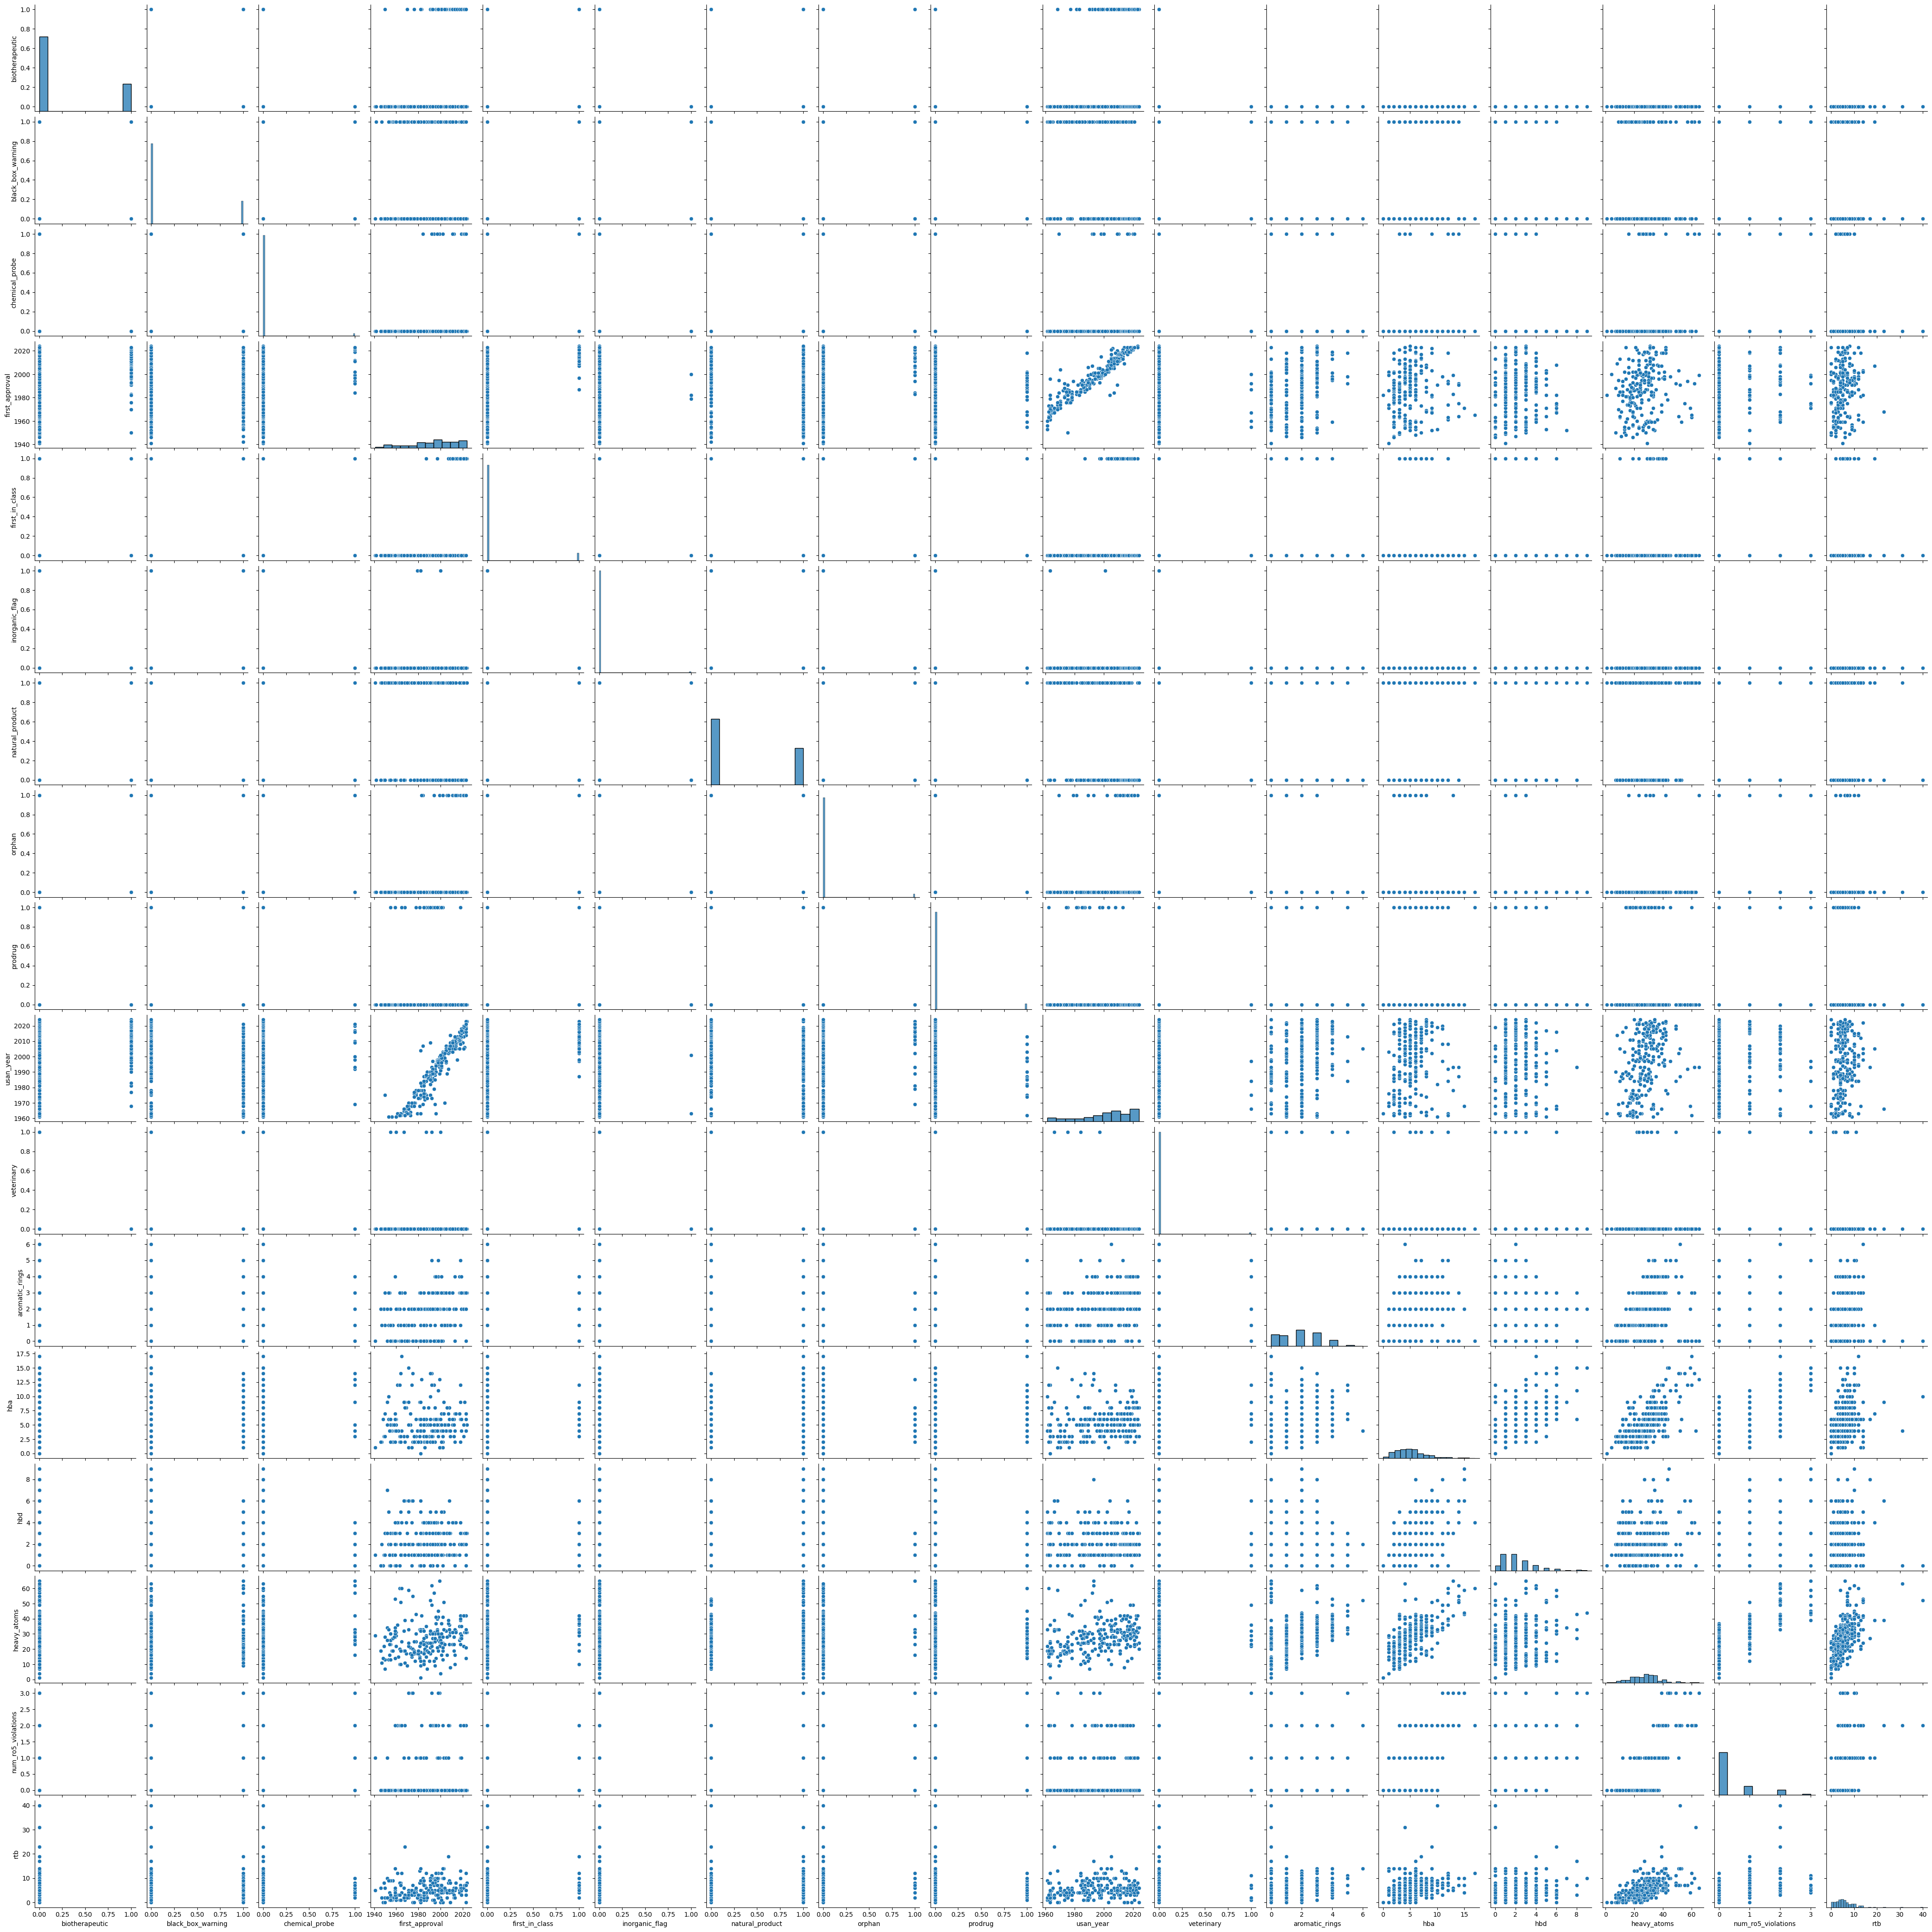

In [26]:
import seaborn as sns
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
test = final_drugs_df.select_dtypes(include=numerics)
sns.pairplot(test, kind="scatter")


In [ ]:
final_diseases_df

,disease_id,name,description,associatedTargets,phenotypes,ensembl_ids,uniprot_ids,target_evidence
0,EFO_0000685,rheumatoid arthritis,"A chronic, systemic autoimmune disorder charac...","{'rows': [{'target': {'id': 'ENSG00000160712',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0001370'...,"[ENSG00000160712, ENSG00000105397, ENSG0000023...","[H0Y9B1, K7EM33, A0A8V8TNL2, A0A1B0GVR5, F5H2S8]","[[{'target': {'id': 'ENSG00000232810'}, 'score..."
1,EFO_0004991,Myasthenia gravis,"Myasthenia gravis (MG) is a rare, clinically h...","{'rows': [{'target': {'id': 'ENSG00000171385',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000651'...,"[ENSG00000171385, ENSG00000170745, ENSG0000014...","[Q9UK17, C9J187, Q8NCM2, F8WD68, Q8TDN2]","[[{'target': {'id': 'ENSG00000140015'}, 'score..."
2,EFO_0002609,juvenile idiopathic arthritis,"Juvenile idiopathic arthritis (JIA), also know...","{'rows': [{'target': {'id': 'ENSG00000179630',...",{'rows': []},"[ENSG00000179630, ENSG00000232810, ENSG0000007...","[A2A3Z5, A0A8V8TNL2, Q6ZYK7, X6RJD6, Q3MSN4]","[[{'target': {'id': 'ENSG00000073756'}, 'score..."
3,EFO_0005297,Granulomatosis with Polyangiitis,A small-vessel necrotizing vasculitis characte...,"{'rows': [{'target': {'id': 'ENSG00000156738',...",{'rows': []},"[ENSG00000156738, ENSG00000197405, ENSG0000012...","[E9PPL6, M0QZK7, D6RE15, C9JQP9, Q3MSN4]","[[{'target': {'id': 'ENSG00000156738'}, 'score..."
4,EFO_0004254,membranous glomerulonephritis,A type of glomerulonephritis that is character...,"{'rows': [{'target': {'id': 'ENSG00000153246',...",{'rows': []},"[ENSG00000153246, ENSG00000115221, ENSG0000015...","[Q13018, F8WBJ8, E9PPL6, Q3MSN4, H0Y4R1]","[[{'target': {'id': 'ENSG00000153246'}, 'score..."
5,EFO_0004194,IGA glomerulonephritis,Inflammation of a specific segment of glomerul...,"{'rows': [{'target': {'id': 'ENSG00000161955',...",{'rows': []},"[ENSG00000161955, ENSG00000144891, ENSG0000013...","[Q2QBA2, D3DNG8, O43597, P25101, Q5TFM2]","[[{'target': {'id': 'ENSG00000136158'}, 'score..."
6,EFO_0004719,pemphigus vulgaris,Pemphigus is a group of chronic autoimmune ski...,"{'rows': [{'target': {'id': 'ENSG00000113580',...",{'rows': []},"[ENSG00000113580, ENSG00000156738, ENSG0000010...","[Q3MSN4, E9PPL6, H7C5T1, H0Y4R1, P32926]","[[{'target': {'id': 'ENSG00000113580'}, 'score..."
7,EFO_0000699,Sjogren syndrome,Chronic inflammatory and autoimmune disease in...,"{'rows': [{'target': {'id': 'ENSG00000128604',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000007'...,"[ENSG00000128604, ENSG00000133019, ENSG0000016...","[F8WDH6, B1AN12, F5GZF8, Q96RJ3, E9PG69]","[[{'target': {'id': 'ENSG00000133019'}, 'score..."
8,EFO_0004237,Graves disease,Graves' disease is an autoimmune disorder that...,"{'rows': [{'target': {'id': 'ENSG00000134242',...",{'rows': []},"[ENSG00000134242, ENSG00000101017, ENSG0000014...","[F5H2S8, H0YE23, H3BSZ8, H0YBY1, Q0VAP8]","[[{'target': {'id': 'ENSG00000140443'}, 'score..."
9,EFO_1000684,dermatitis herpetiformis,Dermatitis herpetiformis (DH) is a chronic aut...,"{'rows': [{'target': {'id': 'ENSG00000113580',...",{'rows': []},"[ENSG00000113580, ENSG00000064999, ENSG0000011...","[Q3MSN4, A0A8V8TP68, H7C4E2, H3BLV9, H0Y420]","[[{'target': {'id': 'ENSG00000113580'}, 'score..."


In [27]:
final_diseases_df

,disease_id,name,description,associatedTargets,phenotypes,ensembl_ids,uniprot_ids,target_evidence
0,EFO_0000685,rheumatoid arthritis,"A chronic, systemic autoimmune disorder charac...","{'rows': [{'target': {'id': 'ENSG00000160712',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0001370'...,"[ENSG00000160712, ENSG00000105397, ENSG0000023...","[H0Y9B1, K7EM33, A0A8V8TNL2, A0A1B0GVR5, F5H2S8]","[[{'target': {'id': 'ENSG00000232810'}, 'score..."
1,EFO_0004991,Myasthenia gravis,"Myasthenia gravis (MG) is a rare, clinically h...","{'rows': [{'target': {'id': 'ENSG00000171385',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000651'...,"[ENSG00000171385, ENSG00000170745, ENSG0000014...","[Q9UK17, C9J187, Q8NCM2, F8WD68, Q8TDN2]","[[{'target': {'id': 'ENSG00000140015'}, 'score..."
2,EFO_0002609,juvenile idiopathic arthritis,"Juvenile idiopathic arthritis (JIA), also know...","{'rows': [{'target': {'id': 'ENSG00000179630',...",{'rows': []},"[ENSG00000179630, ENSG00000232810, ENSG0000007...","[A2A3Z5, A0A8V8TNL2, Q6ZYK7, X6RJD6, Q3MSN4]","[[{'target': {'id': 'ENSG00000073756'}, 'score..."
3,EFO_0004826,anti-neutrophil antibody associated vasculitis,Group of systemic vasculitis with a strong ass...,"{'rows': [{'target': {'id': 'ENSG00000197249',...",{'rows': []},"[ENSG00000197249, ENSG00000113580, ENSG0000015...","[G3V5R8, Q3MSN4, E9PPL6, D6RE15, M0QZK7]","[[{'target': {'id': 'ENSG00000197249'}, 'score..."
4,EFO_0005297,Granulomatosis with Polyangiitis,A small-vessel necrotizing vasculitis characte...,"{'rows': [{'target': {'id': 'ENSG00000156738',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000509'...,"[ENSG00000156738, ENSG00000197405, ENSG0000012...","[E9PPL6, M0QZK7, D6RE15, C9JQP9, Q3MSN4]","[[{'target': {'id': 'ENSG00000156738'}, 'score..."
5,EFO_0004254,membranous glomerulonephritis,A type of glomerulonephritis that is character...,"{'rows': [{'target': {'id': 'ENSG00000153246',...",{'rows': []},"[ENSG00000153246, ENSG00000115221, ENSG0000015...","[Q13018, F8WBJ8, E9PPL6, Q3MSN4, H0Y4R1]","[[{'target': {'id': 'ENSG00000153246'}, 'score..."
6,EFO_0004194,IGA glomerulonephritis,Inflammation of a specific segment of glomerul...,"{'rows': [{'target': {'id': 'ENSG00000161955',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000979'...,"[ENSG00000161955, ENSG00000144891, ENSG0000013...","[Q2QBA2, D3DNG8, O43597, P25101, Q5TFM2]","[[{'target': {'id': 'ENSG00000136158'}, 'score..."
7,EFO_0004719,pemphigus vulgaris,Pemphigus is a group of chronic autoimmune ski...,"{'rows': [{'target': {'id': 'ENSG00000113580',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0002960'...,"[ENSG00000113580, ENSG00000156738, ENSG0000010...","[Q3MSN4, E9PPL6, H7C5T1, H0Y4R1, P32926]","[[{'target': {'id': 'ENSG00000113580'}, 'score..."
8,EFO_0000699,Sjogren syndrome,Chronic inflammatory and autoimmune disease in...,"{'rows': [{'target': {'id': 'ENSG00000128604',...",{'rows': [{'phenotypeHPO': {'id': 'HP_0000007'...,"[ENSG00000128604, ENSG00000133019, ENSG0000016...","[F8WDH6, B1AN12, F5GZF8, Q96RJ3, E9PG69]","[[{'target': {'id': 'ENSG00000133019'}, 'score..."
9,EFO_0004237,Graves disease,Graves' disease is an autoimmune disorder that...,"{'rows': [{'target': {'id': 'ENSG00000134242',...",{'rows': []},"[ENSG00000134242, ENSG00000101017, ENSG0000014...","[F5H2S8, H0YE23, H3BSZ8, H0YBY1, Q0VAP8]","[[{'target': {'id': 'ENSG00000140443'}, 'score..."


In [ ]:
final_indications_df

,drug_id,efo_term,efo_id,mesh_id,max_phase_for_ind,nct_evidence,indication_refs,nct_ids
0,CHEMBL1201823,rheumatoid arthritis,EFO:0000685,D001172,4.0,"[success3, unknown3, unknown3, success3]","[{'ref_id': 'NCT00048568,NCT00048581,NCT000489...","[NCT00048568, NCT00048581, NCT00048932, NCT000..."
1,CHEMBL1201580,rheumatoid arthritis,EFO:0000685,D001172,4.0,"[success3, success3, success3, unknown4, unkno...","[{'ref_id': 'NCT00049751,NCT00195650,NCT001956...","[NCT00049751, NCT00195650, NCT00195663, NCT001..."
2,CHEMBL1542,Myasthenia gravis,EFO:0004991,D009157,3.0,[],"[{'ref_id': 'NCT01727193', 'ref_type': 'Clinic...",[NCT01727193]
3,CHEMBL1201834,juvenile idiopathic arthritis,EFO:0002609,D001171,4.0,[],"[{'ref_id': 'NCT00426218', 'ref_type': 'Clinic...",[NCT00426218]
4,CHEMBL118,juvenile idiopathic arthritis,EFO:0002609,D001171,4.0,[unknown4],"[{'ref_id': 'NCT00652925,NCT00807846', 'ref_ty...","[NCT00652925, NCT00807846]"
...,...,...,...,...,...,...,...,...
1251,CHEMBL6068475,systemic lupus erythematosus,MONDO:0007915,D008180,1.0,None,"[{'ref_id': 'ZOLACABTAGENE AUTOLEUCEL', 'ref_t...",None
1252,CHEMBL6068160,systemic lupus erythematosus,MONDO:0007915,D008180,2.0,[],"[{'ref_id': 'NCT01405196', 'ref_type': 'Clinic...",[NCT01405196]
1253,CHEMBL6068503,Graves ophthalmopathy,EFO:1001466,D049970,2.0,[],"[{'ref_id': 'NCT02393183', 'ref_type': 'Clinic...",[NCT02393183]
1254,CHEMBL6068583,type 1 diabetes mellitus,MONDO:0005147,D003922,1.0,[],"[{'ref_id': 'NCT03272269', 'ref_type': 'Clinic...",[NCT03272269]


In [ ]:
final_trials_df

,nct_id,success,median_p_value,phase,status,hasResults,why_stopped,resultsSection,p_value_list,start_date,end_date
0,NCT00000429,None,None,2,COMPLETED,False,None,NaN,None,1996-06,2001-05
1,NCT00004190,None,None,2,COMPLETED,False,None,NaN,None,1999-10,2003-06
2,NCT00004210,None,None,None,COMPLETED,False,None,NaN,None,2000-02,2011-06
3,NCT00001761,None,None,1,COMPLETED,False,None,NaN,None,1998-02,2000-04
4,NCT00001901,None,None,2,COMPLETED,False,None,NaN,None,1999-02,2005-03
...,...,...,...,...,...,...,...,...,...,...,...
1309,NCT06350630,None,None,2,NOT_YET_RECRUITING,False,None,NaN,None,2025-06,2030-12-31
1310,NCT06392386,None,None,3,RECRUITING,False,None,NaN,None,2024-06-28,2026-09-30
1311,NCT06454110,None,None,2,NOT_YET_RECRUITING,False,None,NaN,None,2025-11,2027-07
1312,NCT06471361,None,None,3,COMPLETED,False,None,NaN,None,2024-08-27,2025-02-03
